# Breast Cancer Logistic Regression Model

### Libraries

In [72]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
import pickle

### Loading Data

In [5]:
data = load_breast_cancer()
# list of features
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### Exploratory Data Analysis

In [15]:
df_target = pd.DataFrame(data.target, columns = ['Target'])
df_data = pd.DataFrame(data.data, columns = data.feature_names)

In [14]:
df_data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
df_target.head()

,Target
0,0
1,0
2,0
3,0
4,0


### Distribution plots

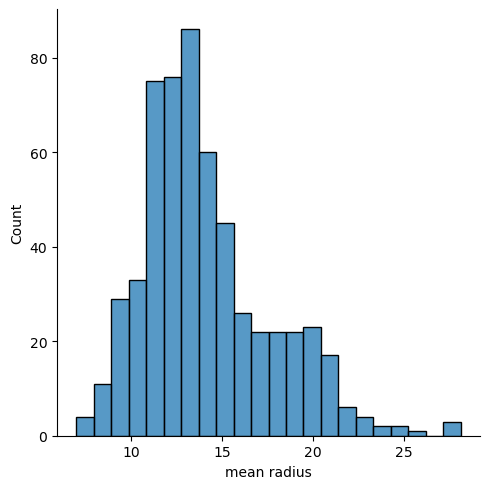

In [18]:
sns.displot(df_data['mean radius'])
plt.show()

#### This data feature(`mean radius`)  contains linear data as it forms a cone shape slightly skewed to the right.

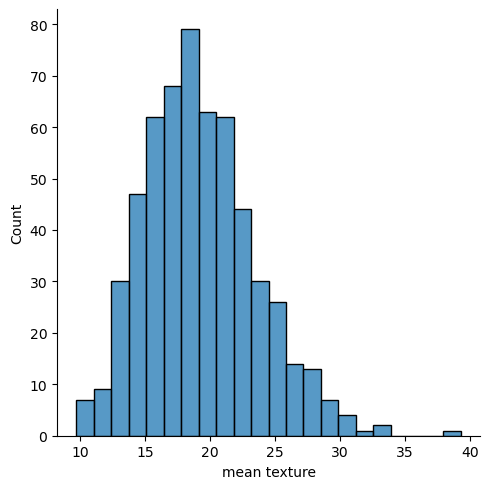

In [19]:
sns.displot(df_data['mean texture'])
plt.show()

#### `mean  texture` also forms normal distribution slightly skewed to the right

### Correlation Heatmaps

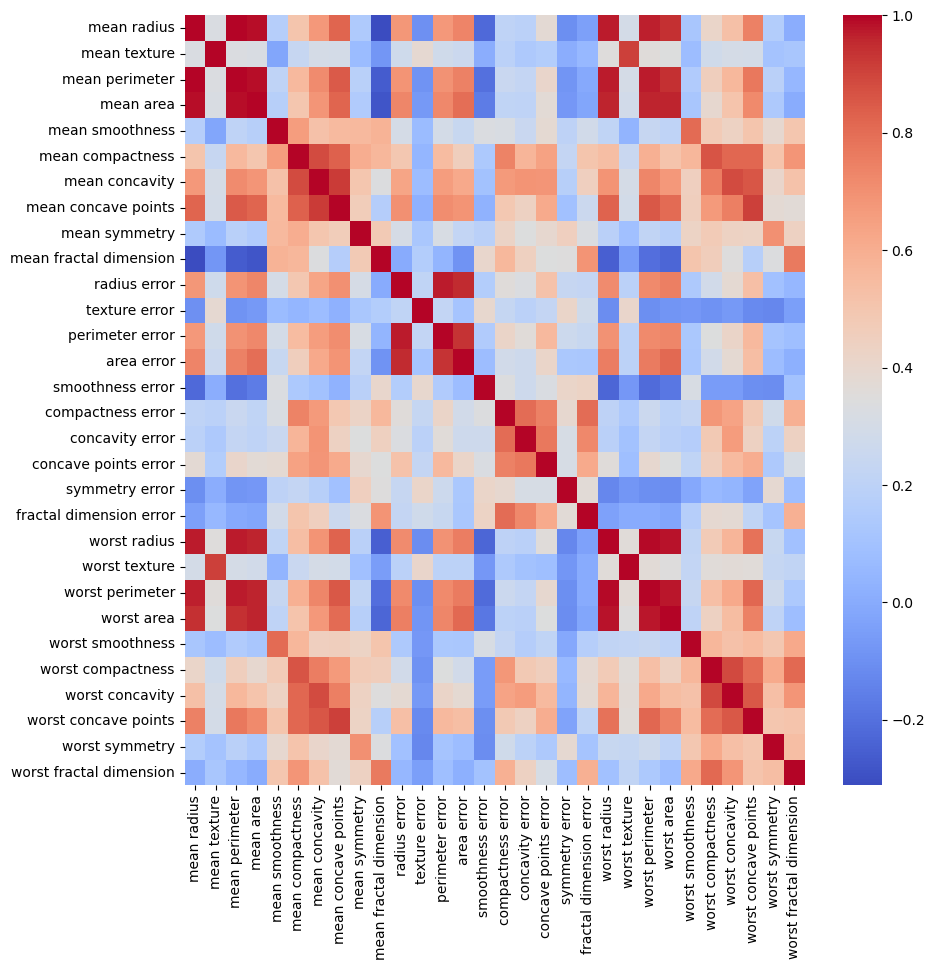

In [24]:
plt.figure(figsize = (10, 10))
sns.heatmap(
    df_data.corr(),
    annot = False,
    cmap = 'coolwarm'
)
plt.show()

### Balance of the Target Variable

<Axes: xlabel='Target', ylabel='count'>

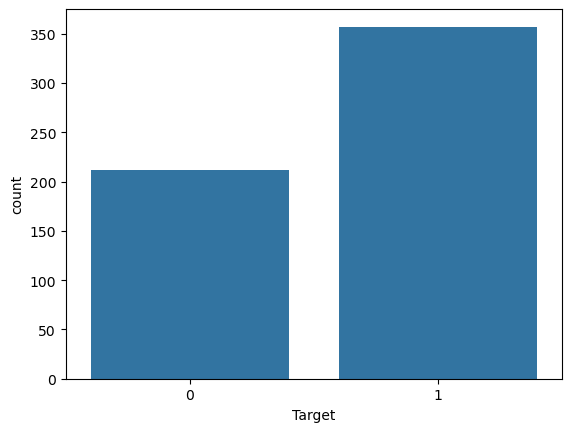

In [28]:
sns.countplot(
    x = 'Target',
    data = df_target
)

### Data Preparation

#### 1. Split Dataset

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size = 0.2,
    random_state = 42,
    stratify = data.target
)

#### 2. Normalise the features

In [33]:
scale = StandardScaler()

In [37]:
x_train_scaled = scale.fit_transform(X_train)
x_test_scaled = scale.transform(X_test)

#### 3.Train Model

In [45]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Model evaluation and interpretation

In [47]:
accuracy = accuracy_score(
    y_test,
    model.predict(
        x_test_scaled
    )
)

conf_matrix = confusion_matrix(
    y_test,
    model.predict(
        x_test_scaled
    )
)

class_report = classification_report(
    y_test,
    model.predict(
        x_test_scaled
    )
)

In [48]:
print(f"Accuracy: {accuracy}\nConfusion matrix: {conf_matrix}\nclassification Report: {class_report}")

Accuracy: 0.9824561403508771
Confusion matrix: [[41  1]
 [ 1 71]]
classification Report:               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [57]:
importance = pd.DataFrame(model.coef_[0], index = data.feature_names, columns = ['coefficient'])
importance.sort_values('coefficient', ascending = False)

,coefficient
mean compactness,0.648342
compactness error,0.647227
fractal dimension error,0.437894
symmetry error,0.360492
texture error,0.248823
mean fractal dimension,0.199732
concavity error,0.160563
worst compactness,0.055514
smoothness error,-0.160276
mean symmetry,-0.167233


### Model improvement

#### 1. Feature selection:

In [66]:
selector = RFE(
    estimator = LogisticRegression(),
    n_features_to_select = 1,
    step = 1
)

X_train_selected = selector.fit_transform(
    x_train_scaled,
    y_train
)

X_test_selected = selector.transform(x_test_scaled)

#### 2. Hyperparameter tuning

In [70]:
param_grid = {'C' : [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv = 5
)
grid_search.fit(
    X_train_selected,
    y_train
)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [71]:
# Evaluating the best model from GridSearchCV
best_model = grid_search.best_estimator_
best_accuracy = accuracy_score(y_test, best_model.predict(X_test_selected))
best_conf_matrix = confusion_matrix(y_test, best_model.predict(X_test_selected))
best_class_report = classification_report(y_test, best_model.predict(X_test_selected))

# Output the improved results
print(f"Improved Model Accuracy: {best_accuracy}")
print(f"Improved Confusion Matrix:\n{best_conf_matrix}\n")
print(f"Improved Classification Report:\n{best_class_report}")

Improved Model Accuracy: 0.9298245614035088
Improved Confusion Matrix:
[[36  6]
 [ 2 70]]

Improved Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        42
           1       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



### Saving the model

In [73]:
with open("Breast_cancer.pkl", "wb") as file:
    pickle.dump(best_model, file)
    
print("Model saved successfully!")

Model saved successfully!


### Reusing saved model

In [75]:
with open("Breast_cancer.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


# The End